## Задача baseline-анализа

Задача базового эмпирического анализа заключается в том, чтобы оценить способность традиционных финансовых коэффициентов прогнозировать финансовый дистресс компаний сектора недвижимости.

Для этого необходимо:

 - Сформировать панельный датасет публичных компаний сектора недвижимости из выбранных стран за период 2010–2024 гг.

 - Определить состояние финансового дистресса компаний на основе финансовых показателей, отражающих способность обслуживать долговые обязательства и генерировать операционные денежные потоки.

 - Сконструировать набор финансовых коэффициентов, характеризующих:

1) долговую нагрузку,

2) ликвидность,

3) прибыльность,

4) динамику выручки.

 - Построить базовую эконометрическую модель (logistic regression) для оценки вероятности перехода компании в состояние финансового дистресса в следующем периоде.

 - Оценить качество прогноза базовой модели с использованием стандартных метрик классификации, включая:

1) ROC-кривую,

2) AUC,

3) матрицу ошибок.

Проанализировать экономическую интерпретацию коэффициентов, чтобы определить, какие финансовые характеристики наиболее тесно связаны с вероятностью возникновения дистресса.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/DmitryTeb/Real-Estate/main/finance_data_v3.xlsx"

df = pd.read_excel(url)

df = df.rename(columns = {"Report_Year": "Report Year"})
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (6817, 13)

Columns:
['Company Name', 'FY Total Revenue ', 'FY Interest Expense ', 'FY EBIT ', 'FY Total Current Assets ', 'FY Total Assets ', 'FY Total Current Liabilities ', 'FY Total Equity ', 'FY Total Debt ', 'FY Cash from Ops. ', 'Country', 'Primary Industry Classification', 'Report Year']


,Company Name,FY Total Revenue,FY Interest Expense,FY EBIT,FY Total Current Assets,FY Total Assets,FY Total Current Liabilities,FY Total Equity,FY Total Debt,FY Cash from Ops.,Country,Primary Industry Classification,Report Year
0,GuocoLand Limited (SGX:F17),1505.7,-169.32,224.5,3356.9,9722.9,1175.79,4342.8,4728.2,159.34,Singapore,Real Estate Development,2025-01-01
1,Hysan Development Company Limited (SEHK:14),368.1,-55.16,241.1,738.4,14737.6,527.85,9731.3,4432.9,292.14,Hong Kong,Real Estate Operating Companies,2025-01-01
2,WCM Beteiligungs- und Grundbesitz-AG (HMSE:WCMK),91.5,-0.14,7.1,168.92,526.1,10.67,462.3,39.4,0.92,Germany,Real Estate Operating Companies,2025-01-01
3,Pandox AB (publ) (OM:PNDX B),807.5,-259.6,431,1948.43,12098,2213.64,3666.7,5752.7,329.66,Sweden,Real Estate Operating Companies,2025-01-01
4,Harbour Centre Development Limited (SEHK:51),171.7,-1.66,30,216.42,2103.3,107.25,1924.1,56.4,-,Hong Kong,Real Estate Development,2025-01-01


In [2]:
print("Unique companies:", df["Company Name"].nunique())
print("Unique years:", df["Report Year"].nunique())

print("\nYears:")
print(sorted(df["Report Year"].unique()))

Unique companies: 480
Unique years: 23

Years:
[Timestamp('2014-01-01 00:00:00'), Timestamp('2014-12-31 00:00:00'), Timestamp('2015-01-01 00:00:00'), Timestamp('2015-12-31 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2016-12-31 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2018-12-31 00:00:00'), Timestamp('2019-01-01 00:00:00'), Timestamp('2019-12-31 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2021-01-01 00:00:00'), Timestamp('2021-12-31 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2025-01-01 00:00:00')]


In [3]:
df["Year"] = pd.to_datetime(df["Report Year"]).dt.year

print(df["Year"].unique())

[2025 2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014]


In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['Company Name', 'FY Total Revenue', 'FY Interest Expense', 'FY EBIT',
       'FY Total Current Assets', 'FY Total Assets',
       'FY Total Current Liabilities', 'FY Total Equity', 'FY Total Debt',
       'FY Cash from Ops.', 'Country', 'Primary Industry Classification',
       'Report Year', 'Year'],
      dtype='object')

In [5]:
df.dtypes

Company Name                               object
FY Total Revenue                           object
FY Interest Expense                        object
FY EBIT                                    object
FY Total Current Assets                    object
FY Total Assets                            object
FY Total Current Liabilities               object
FY Total Equity                            object
FY Total Debt                              object
FY Cash from Ops.                          object
Country                                    object
Primary Industry Classification            object
Report Year                        datetime64[ns]
Year                                        int32
dtype: object

In [6]:
num_cols = [
    'FY Total Current Assets',
    'FY Total Assets',
    'FY Total Current Liabilities',
    'FY Total Debt',
    'FY Total Equity',
    'FY Total Revenue',
    'FY Interest Expense',
    'FY EBIT',
    'FY Cash from Ops.'
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[num_cols].dtypes

FY Total Current Assets         float64
FY Total Assets                 float64
FY Total Current Liabilities    float64
FY Total Debt                   float64
FY Total Equity                 float64
FY Total Revenue                float64
FY Interest Expense             float64
FY EBIT                         float64
FY Cash from Ops.               float64
dtype: object

In [7]:
df[num_cols].isna().sum().sort_values(ascending=False)

FY Cash from Ops.               397
FY Interest Expense             362
FY Total Debt                   351
FY Total Current Liabilities    350
FY Total Current Assets         347
FY Total Assets                 347
FY Total Equity                 347
FY Total Revenue                342
FY EBIT                         330
dtype: int64

# Шаг 5 — построение финансовых коэффициентов

### Теперь создадим ключевые финансовые коэффициенты для baseline-модели.

In [8]:
# долговая нагрузка
df["Debt_to_Assets"] = df["FY Total Debt"] / df["FY Total Assets"]

# ликвидность
df["Current_Ratio"] = df["FY Total Current Assets"] / df["FY Total Current Liabilities"]

# прибыльность
df["ROA"] = df["FY EBIT"] / df["FY Total Assets"]

# операционный денежный поток к долгу
df["OCF_to_Debt"] = df["FY Cash from Ops."] / df["FY Total Debt"]

# покрытие процентов
df["Interest_Coverage"] = df["FY EBIT"] / df["FY Interest Expense"]

df["Revenue_Growth"] = df["FY Total Revenue"].pct_change(fill_method = None)

df[[
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Interest_Coverage",
    "Revenue_Growth"
]].describe()

C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage,Revenue_Growth
count,6287.000000,6290.000000,6302.000000,6246.000000,6286.000000,6241.000000
mean,inf,inf,NaN,NaN,NaN,inf
std,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,-3.446809,-inf,-inf,-inf,-8.505208
25%,0.311472,0.547898,0.026935,0.062286,-7.764128,-0.302135
50%,0.420027,1.115921,0.035960,0.100984,-3.657614,0.062290
75%,0.492544,2.071000,0.048674,0.144633,-2.071421,0.465511
max,inf,inf,inf,inf,inf,inf


## Шаг 6 — очистка коэффициентов

Сейчас нужно:

заменить inf и -inf на NaN

при желании ограничить экстремальные значения winsorization/clip

In [9]:
import numpy as np

ratio_cols = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Interest_Coverage",
    "Revenue_Growth"
]

df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)

df[ratio_cols].describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage,Revenue_Growth
count,6285.000000,6287.000000,6288.000000,6185.000000,6242.000000,6200.000000
mean,4.571628,3.075912,0.441446,2.601569,-20.169624,5.026247
std,182.525318,32.833599,15.398996,162.340961,688.565634,70.961417
min,0.000000,-3.446809,-4.721154,-81.155556,-53770.000000,-8.505208
25%,0.311448,0.547849,0.026930,0.062282,-7.773895,-0.310124
50%,0.419978,1.115365,0.035948,0.100603,-3.683913,0.060370
75%,0.492367,2.068833,0.048577,0.143449,-2.098231,0.444821
max,9665.000000,1770.615385,727.000000,12737.600000,1760.000000,2873.500000


In [10]:
for col in ratio_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

df[ratio_cols].describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage,Revenue_Growth
count,6285.000000,6287.000000,6288.000000,6185.000000,6242.000000,6200.000000
mean,0.404322,2.003464,0.038851,0.121371,-7.382160,1.946432
std,0.150489,3.133374,0.023580,0.178591,14.520858,8.095914
min,0.000316,0.051918,-0.022447,-0.360953,-116.047875,-0.997927
25%,0.311448,0.547849,0.026930,0.062282,-7.773895,-0.310124
50%,0.419978,1.115365,0.035948,0.100603,-3.683913,0.060370
75%,0.492367,2.068833,0.048577,0.143449,-2.098231,0.444821
max,0.794070,21.828345,0.136791,1.320208,4.908158,62.455371


In [11]:
df["Interest_Coverage"] = df["FY EBIT"] / df["FY Interest Expense"].abs()

In [12]:
df["Distress"] = ((df["Interest_Coverage"] < 1) & (df["FY Cash from Ops."] < 0)).astype(int)

df["Distress"].value_counts()

Distress
0    6687
1     130
Name: count, dtype: int64

In [13]:
df["Distress"].value_counts(normalize=True)

Distress
0    0.98093
1    0.01907
Name: proportion, dtype: float64

# Шаг 8 — формирование target (t+1)

### Модель должна предсказывать:

### 𝐷𝑖𝑠𝑡𝑟𝑒𝑠𝑠_(𝑡+1)

### используя финансовые коэффициенты из периода t.

### Для этого нужно сдвинуть distress на один год вперёд внутри каждой компании.

In [14]:
df[ratio_cols].describe()

C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage,Revenue_Growth
count,6285.000000,6287.000000,6288.000000,6185.000000,6286.000000,6200.000000
mean,0.404322,2.003464,0.038851,0.121371,NaN,1.946432
std,0.150489,3.133374,0.023580,0.178591,NaN,8.095914
min,0.000316,0.051918,-0.022447,-0.360953,-inf,-0.997927
25%,0.311448,0.547849,0.026930,0.062282,2.128287,-0.310124
50%,0.419978,1.115365,0.035948,0.100603,3.747713,0.060370
75%,0.492367,2.068833,0.048577,0.143449,7.928364,0.444821
max,0.794070,21.828345,0.136791,1.320208,inf,62.455371


In [15]:
df = df.sort_values(["Company Name", "Year"])

df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

df[["Company Name","Year","Distress","Distress_next_year"]].head(10)

,Company Name,Year,Distress,Distress_next_year
3341,AB Sagax (publ) (OM:SAGA A),2014,0,0.0
3044,AB Sagax (publ) (OM:SAGA A),2015,0,0.0
2747,AB Sagax (publ) (OM:SAGA A),2016,0,0.0
2450,AB Sagax (publ) (OM:SAGA A),2017,0,0.0
2153,AB Sagax (publ) (OM:SAGA A),2018,0,0.0
1856,AB Sagax (publ) (OM:SAGA A),2019,0,0.0
1559,AB Sagax (publ) (OM:SAGA A),2020,0,0.0
1262,AB Sagax (publ) (OM:SAGA A),2021,0,0.0
965,AB Sagax (publ) (OM:SAGA A),2022,0,0.0
668,AB Sagax (publ) (OM:SAGA A),2023,0,0.0


In [16]:
df = df.sort_values(["Company Name", "Year"])

df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

df[["Company Name","Year","Distress","Distress_next_year"]].head(10)

,Company Name,Year,Distress,Distress_next_year
3341,AB Sagax (publ) (OM:SAGA A),2014,0,0.0
3044,AB Sagax (publ) (OM:SAGA A),2015,0,0.0
2747,AB Sagax (publ) (OM:SAGA A),2016,0,0.0
2450,AB Sagax (publ) (OM:SAGA A),2017,0,0.0
2153,AB Sagax (publ) (OM:SAGA A),2018,0,0.0
1856,AB Sagax (publ) (OM:SAGA A),2019,0,0.0
1559,AB Sagax (publ) (OM:SAGA A),2020,0,0.0
1262,AB Sagax (publ) (OM:SAGA A),2021,0,0.0
965,AB Sagax (publ) (OM:SAGA A),2022,0,0.0
668,AB Sagax (publ) (OM:SAGA A),2023,0,0.0


# Шаг 9 — формирование выборки модели

### Теперь выбираем объясняющие переменные baseline-модели.

In [17]:
# сортируем панель
df = df.sort_values(["Company Name", "Year"])

# создаём distress следующего года
df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

# удаляем последние годы компаний (где нет t+1)
df_model = df.dropna(subset=["Distress_next_year"]).copy()

print("Model dataset shape:", df_model.shape)

Model dataset shape: (6337, 22)


In [18]:
features = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth"
]

X = df_model[features]
y = df_model["Distress_next_year"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (6337, 5)
y shape: (6337,)


,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth
3341,0.627436,0.318914,0.061740,0.069260,0.484925
3044,0.614763,0.385787,0.058729,0.069562,0.346191
2747,0.563851,0.246558,0.054444,0.074995,-0.296127
2450,0.515347,0.159584,0.054394,0.083199,0.414976
2153,0.469115,0.187030,0.051557,0.100603,0.510572


In [19]:
X.isna().sum()

Debt_to_Assets    527
Current_Ratio     525
ROA               524
OCF_to_Debt       604
Revenue_Growth    609
dtype: int64

# Шаг 10 — обработка пропусков

### Самый простой и корректный baseline-подход — удалить наблюдения с пропусками.

In [20]:
import numpy as np

data = pd.concat([X, y], axis=1)

data = data.dropna()

print("Clean dataset shape:", data.shape)

Clean dataset shape: (5606, 6)


In [21]:
X_clean = data[features]
y_clean = data["Distress_next_year"]

print("X_clean:", X_clean.shape)
print("y_clean:", y_clean.shape)

X_clean: (5606, 5)
y_clean: (5606,)


# EDA анализ

## Шаг 10.1 — описательная статистика коэффициентов

In [22]:
X_clean.describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth
count,5606.000000,5606.000000,5606.000000,5606.000000,5606.000000
mean,0.406532,1.966567,0.039231,0.122856,2.048391
std,0.145011,3.019038,0.022736,0.178990,8.263967
min,0.000316,0.051918,-0.022447,-0.360953,-0.997927
25%,0.314190,0.561774,0.027481,0.064108,-0.279034
50%,0.420045,1.122988,0.036130,0.101428,0.066362
75%,0.490471,2.060069,0.048589,0.144370,0.493816
max,0.794070,21.828345,0.136791,1.320208,62.455371


### Это типичные показатели для REIT и real estate компаний, которые используют высокий leverage.

## Шаг 10.2 — сравнение distress vs non-distress

In [23]:
data_clean = pd.concat([X_clean, y_clean], axis=1)

data_clean.groupby("Distress_next_year")[features].mean()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth
Distress_next_year,,,,,
0.0,0.407614,1.934460,0.039801,0.124792,2.079237
1.0,0.346918,3.734389,0.007868,0.016278,0.349976


### Компании в distress:

#### имеют более высокую долговую нагрузку

#### имеют значительно более низкую прибыльность

#### генерируют меньше операционного денежного потока относительно долга

#### Это соответствует теории финансового дистресса.

## Шаг 10.3 — корреляционная матрица

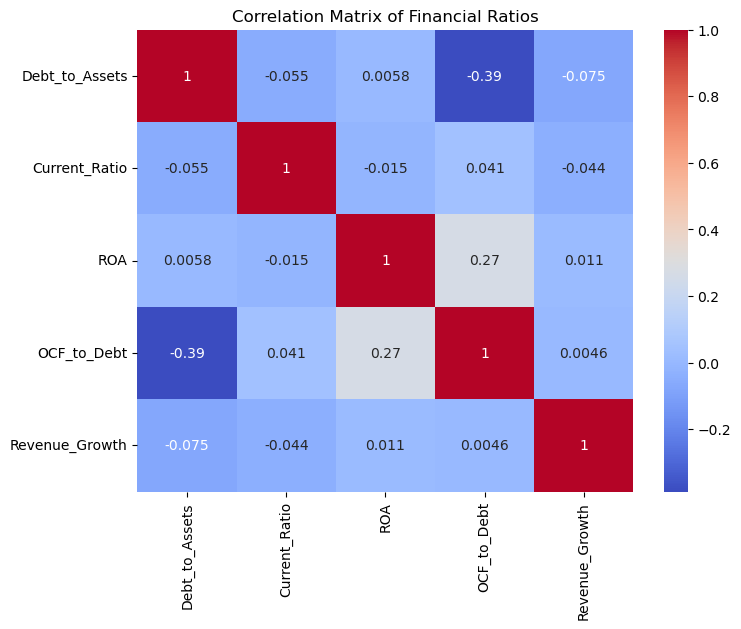

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(X_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Financial Ratios")
plt.show()

### сильной мультиколлинеарности нет

# Шаг 11 — Logistic Regression

Logit AUC: 0.7806295399515738
Best threshold: 0.5
Best F1: 0.15172413793103448

Confusion matrix:
[[1414  238]
 [   8   22]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92      1652
         1.0       0.08      0.73      0.15        30

    accuracy                           0.85      1682
   macro avg       0.54      0.79      0.54      1682
weighted avg       0.98      0.85      0.91      1682



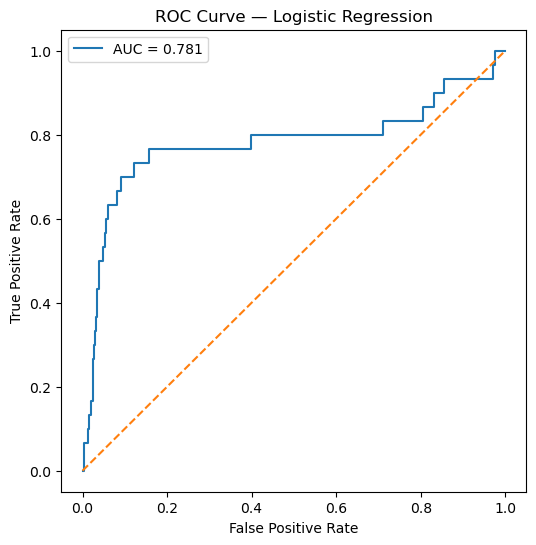

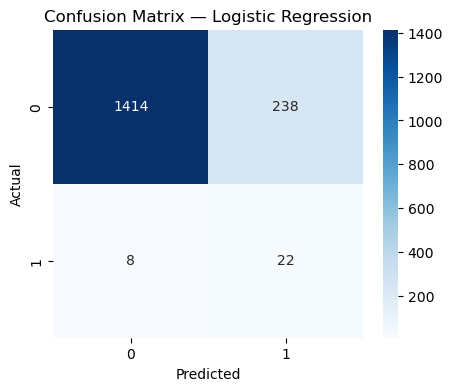


Logistic regression coefficients:
          Feature  Coefficient
1   Current_Ratio     0.129208
4  Revenue_Growth    -0.055841
0  Debt_to_Assets    -1.226031
3     OCF_to_Debt    -5.473770
2             ROA   -13.953593


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

# 2. Логистическая регрессия
logit = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logit.fit(X_train, y_train)

# 3. Вероятности и AUC
y_proba_logit = logit.predict_proba(X_test)[:, 1]
auc_logit = roc_auc_score(y_test, y_proba_logit)

print("Logit AUC:", auc_logit)

# 4. Подбор threshold по F1
thresholds = np.linspace(0.01, 0.5, 100)
f1_scores = []

for t in thresholds:
    pred = (y_proba_logit >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred))

best_idx = np.argmax(f1_scores)
best_thr_logit = thresholds[best_idx]
best_f1_logit = f1_scores[best_idx]

print("Best threshold:", best_thr_logit)
print("Best F1:", best_f1_logit)

# 5. Финальные предсказания
y_pred_logit = (y_proba_logit >= best_thr_logit).astype(int)

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred_logit)
print("\nConfusion matrix:")
print(cm)

# 7. Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred_logit, zero_division=0))

# 8. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_logit)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_logit:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

# 9. Визуализация confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# 10. Коэффициенты модели
coef_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": logit.coef_[0]
    })
    .sort_values("Coefficient", ascending=False)
)

print("\nLogistic regression coefficients:")
print(coef_df)



# Следующий шаг — ML benchmark

### Теперь сделаем Random Forest, чтобы сравнить:

###  1) эконометрическую модель

###  2) модель машинного обучения


# Шаг 14 — Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

print("Random Forest trained")

Random Forest trained


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

print(X_train.shape, X_test.shape)

(3924, 5) (1682, 5)


In [28]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
 y_proba_rf = rf.predict_proba(X_test)[:,1]


In [30]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(y_test, y_proba_rf)

print("RF AUC:", auc_rf)

RF AUC: 0.9107849071832123


In [31]:
# print(y_proba_rf)

In [32]:
thresholds = np.linspace(0.02, 0.5, 100)
f1_scores = []

for t in thresholds:
    pred = (y_proba_rf >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred))

# либо авто:
best_thr_rf = thresholds[np.argmax(f1_scores)]

# либо вручную:
#best_thr_rf = 0.25

# пересчёт F1
y_pred_rf = (y_proba_rf >= best_thr_rf).astype(int)
best_f1_rf = f1_score(y_test, y_pred_rf)


print("Best threshold:",best_thr_rf)
print("Best F1:",best_f1_rf)

Best threshold: 0.4951515151515152
Best F1: 0.5057471264367817


In [33]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,ROA,0.414845
3,OCF_to_Debt,0.267070
1,Current_Ratio,0.154066
4,Revenue_Growth,0.089134
0,Debt_to_Assets,0.074885


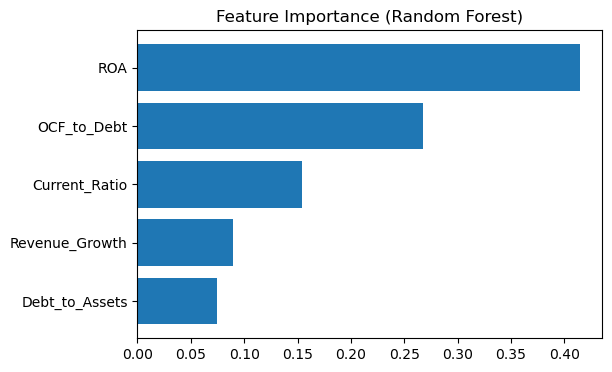

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

In [35]:
print(best_thr_rf)
print(best_f1_rf)

0.4951515151515152
0.5057471264367817


In [36]:
# 11. Feature importance
importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature importance:")
print(importance)


Feature importance:
          Feature  Importance
2             ROA    0.414845
3     OCF_to_Debt    0.267070
1   Current_Ratio    0.154066
4  Revenue_Growth    0.089134
0  Debt_to_Assets    0.074885


In [37]:
print(best_thr_rf)
print(best_f1_rf)

0.4951515151515152
0.5057471264367817


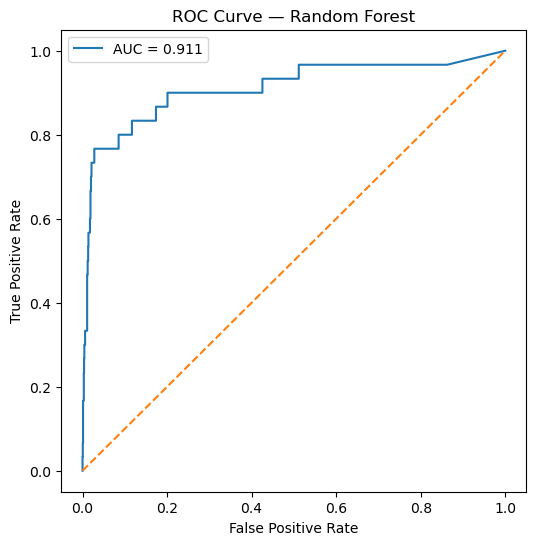

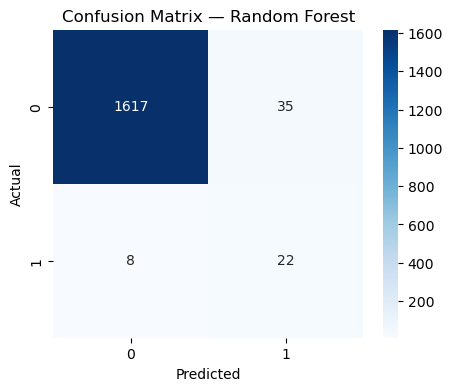

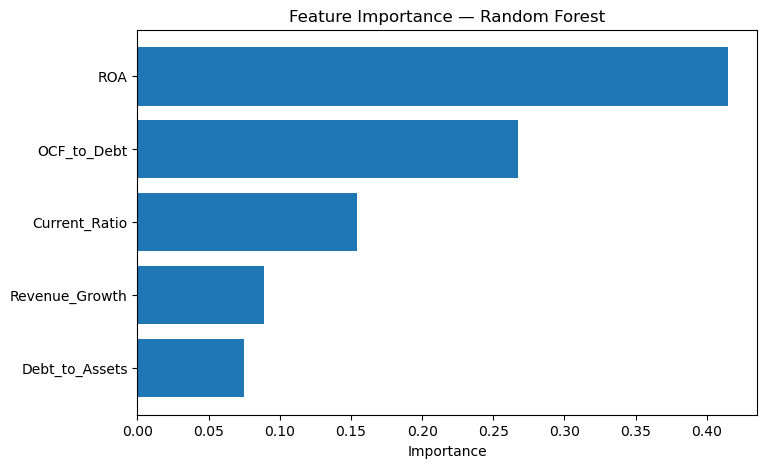

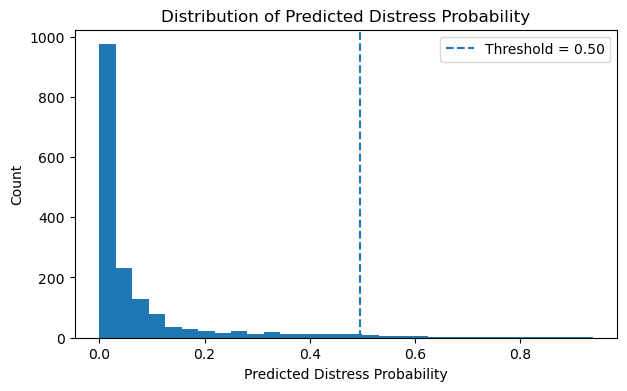

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth,Actual,Predicted_Probability,Predicted_Class
6795,0.369135,1.284324,-0.022447,-0.041370,-0.203583,1.0,0.938241,1
1148,0.185915,3.383403,0.000985,0.001589,-0.695378,0.0,0.919176,1
1151,0.259864,6.309753,-0.002386,-0.000141,-0.830961,1.0,0.912015,1
1745,0.255240,21.806011,-0.003288,-0.070773,-0.742857,0.0,0.908326,1
1085,0.222538,2.363050,-0.001977,-0.055913,-0.810972,1.0,0.902207,1
491,0.211372,1.026730,-0.006057,-0.070585,-0.834262,1.0,0.899605,1
6759,0.344576,1.216136,-0.013624,-0.009884,-0.538339,1.0,0.898629,1
4974,0.477192,21.828345,-0.022447,-0.049911,-0.710013,0.0,0.871743,1
2872,0.567990,4.357612,-0.001827,-0.053405,-0.714822,0.0,0.854488,1
6354,0.268312,4.792929,-0.022447,-0.145687,-0.759774,0.0,0.853643,1


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# 1. ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.show()


# 2. Confusion matrix
y_pred_rf = (y_proba_rf >= best_thr_rf).astype(int)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()


# 3. Feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — Random Forest")
plt.show()


# 4. Распределение вероятностей distress
plt.figure(figsize=(7, 4))
plt.hist(y_proba_rf, bins=30)
plt.axvline(best_thr_rf, linestyle="--", label=f"Threshold = {best_thr_rf:.2f}")
plt.xlabel("Predicted Distress Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Distress Probability")
plt.legend()
plt.show()


# 5. Top-15 наблюдений по риску
results_vis = X_test.copy()
results_vis["Actual"] = y_test.values
results_vis["Predicted_Probability"] = y_proba_rf
results_vis["Predicted_Class"] = y_pred_rf

top_risk = results_vis.sort_values("Predicted_Probability", ascending=False).head(15)
display(top_risk)


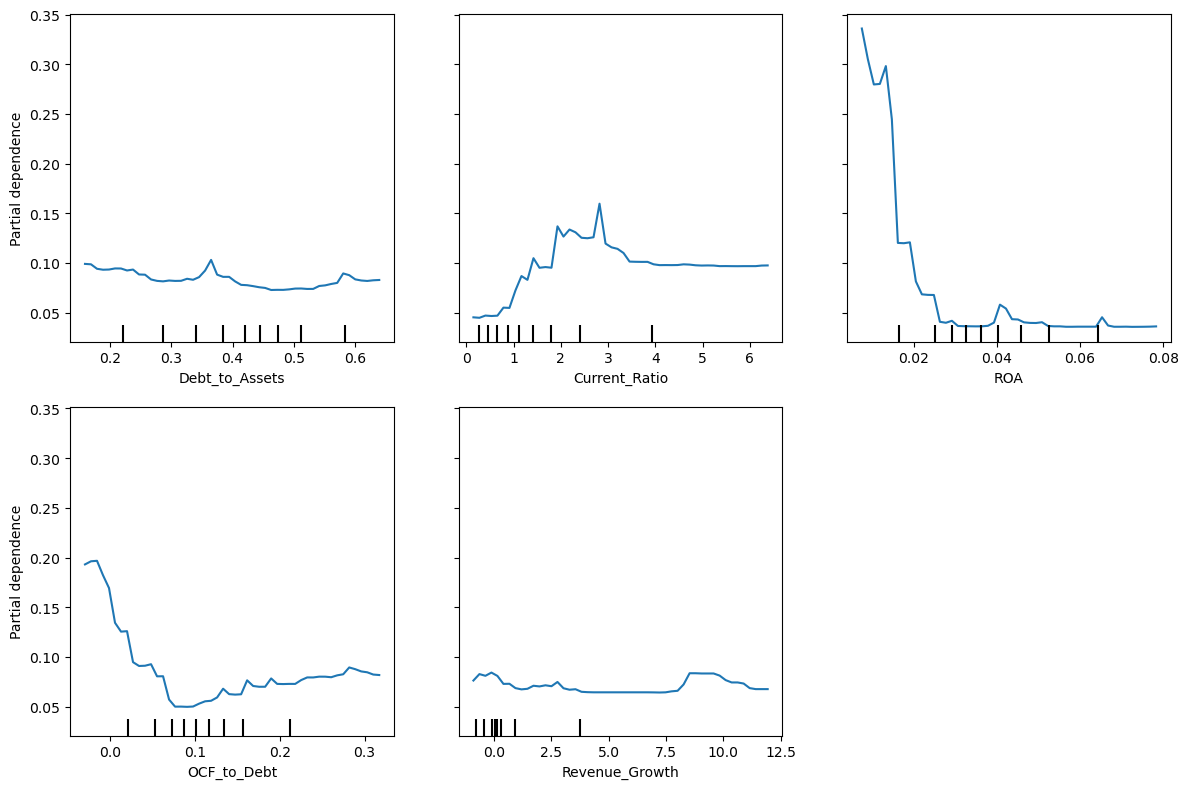

In [39]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth"
    #,"Interest_Coverage"
]

fig, ax = plt.subplots(figsize=(12,8))

PartialDependenceDisplay.from_estimator(
    rf,
    X_clean,
    features,
    grid_resolution=50,
    ax=ax
)

plt.tight_layout()
plt.show()

In [40]:
#!pip install xgboost

# XGBoost

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import numpy as np

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

# вероятности
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# AUC
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("XGB AUC:", auc_xgb)

# подбор threshold
thresholds = np.linspace(0.01, 0.5, 100)
f1_scores = []

for t in thresholds:
    pred = (y_proba_xgb >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred, zero_division=0))

best_idx = np.argmax(f1_scores)
#best_thr_xgb = 0.2
best_thr_xgb = thresholds[best_idx]
# пересчёт F1
y_pred_xgb = (y_proba_xgb >= best_thr_xgb).astype(int)
best_f1_xgb = f1_score(y_test, y_pred_xgb)

# best_f1_xgb = f1_scores[best_idx]

print("Best threshold:", best_thr_xgb)
print("Best F1:", best_f1_xgb)

# финальные предсказания
y_pred_xgb = (y_proba_xgb >= best_thr_xgb).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

cm = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion matrix:")
print(cm)
print("FN (XGB):", cm[1, 0])



C:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:50:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB AUC: 0.8961259079903148
Best threshold: 0.5
Best F1: 0.5230769230769231

Classification report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1652
         1.0       0.49      0.57      0.52        30

    accuracy                           0.98      1682
   macro avg       0.74      0.78      0.76      1682
weighted avg       0.98      0.98      0.98      1682


Confusion matrix:
[[1634   18]
 [  13   17]]
FN (XGB): 13


# Probit

In [42]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import numpy as np

# 1. Добавляем константу
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 2. Обучаем Probit
probit_model = sm.Probit(y_train, X_train_sm).fit(disp=0)

# 3. Вероятности
y_proba_probit = probit_model.predict(X_test_sm)

# 4. AUC
auc_probit = roc_auc_score(y_test, y_proba_probit)
print("PROBIT AUC:", auc_probit)

# 5. Подбор threshold
thresholds = np.linspace(0.01, 0.5, 100)
f1_scores = []

for t in thresholds:
    pred = (y_proba_probit >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_thr_probit = thresholds[best_idx]

# 6. Финальные предсказания
y_pred_probit = (y_proba_probit >= best_thr_probit).astype(int)
best_f1_probit = f1_score(y_test, y_pred_probit, zero_division=0)

print("Best threshold:", best_thr_probit)
print("Best F1:", best_f1_probit)

# 7. Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred_probit, zero_division=0))

# 8. Confusion matrix
cm = confusion_matrix(y_test, y_pred_probit)
print("\nConfusion matrix:")
print(cm)
print("FN (Probit):", cm[1, 0])


PROBIT AUC: 0.8292776432606941
Best threshold: 0.08424242424242423
Best F1: 0.3516483516483517

Classification report:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      1652
         1.0       0.26      0.53      0.35        30

    accuracy                           0.96      1682
   macro avg       0.63      0.75      0.67      1682
weighted avg       0.98      0.96      0.97      1682


Confusion matrix:
[[1607   45]
 [  14   16]]
FN (Probit): 14


# Lasso Logistic 

In [43]:
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000
)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
y_proba_lasso = lasso.predict_proba(X_test)[:,1]

print("LASSO AUC:", roc_auc_score(y_test, y_proba_lasso))
print(classification_report(y_test, y_pred_lasso))

cm = confusion_matrix(y_test, y_pred_lasso)
print("FN (Lasso):", cm[1,0])

LASSO AUC: 0.8164648910411623
              precision    recall  f1-score   support

         0.0       1.00      0.85      0.92      1652
         1.0       0.09      0.77      0.16        30

    accuracy                           0.85      1682
   macro avg       0.54      0.81      0.54      1682
weighted avg       0.98      0.85      0.90      1682

FN (Lasso): 7


# Threshold optimization 

In [44]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000, class_weight="balanced")

logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)
y_proba_logit = logit.predict_proba(X_test)[:,1]

In [45]:
results = {
    "Model": ["Logit", "RF", "XGB", 
              "Probit", "Lasso"],
    "AUC": [
        roc_auc_score(y_test, y_proba_logit),
        roc_auc_score(y_test, y_proba_rf),      
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_probit),
        roc_auc_score(y_test, y_proba_lasso),
    ],
    "F1": [
        f1_score(y_test, y_pred_logit),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_probit),
        f1_score(y_test, y_pred_lasso),
    ]

}


results_df = pd.DataFrame(results)
print(results_df)

    Model       AUC        F1
0   Logit  0.780630  0.151724
1      RF  0.910785  0.505747
2     XGB  0.896126  0.523077
3  Probit  0.829278  0.351648
4   Lasso  0.816465  0.155405


In [46]:
display(results_df)

,Model,AUC,F1
0,Logit,0.780630,0.151724
1,RF,0.910785,0.505747
2,XGB,0.896126,0.523077
3,Probit,0.829278,0.351648
4,Lasso,0.816465,0.155405


Confusion Matrix:
[[1617   35]
 [   8   22]]

TN (True Negative): 1617
FP (False Positive): 35
FN (False Negative): 8
TP (True Positive): 22

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      1652
         1.0       0.39      0.73      0.51        30

    accuracy                           0.97      1682
   macro avg       0.69      0.86      0.75      1682
weighted avg       0.98      0.97      0.98      1682



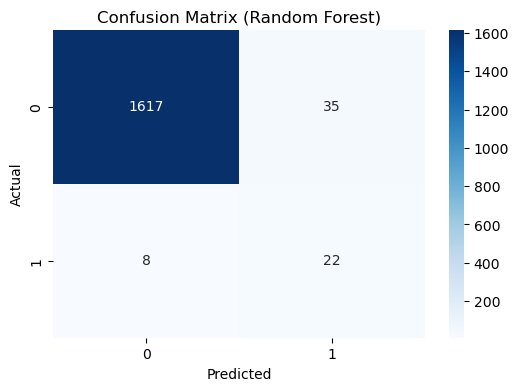

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

# Предсказания
y_pred_rf = (y_proba_rf >= best_thr_rf).astype(int)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Распаковка
tn, fp, fn, tp = cm.ravel()

print(f"\nTN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")

plt.show()


In [48]:
# ==============================
# FALSE NEGATIVES ANALYSIS
# ==============================

import pandas as pd

# 1. Создаём DataFrame с результатами модели
results_test = X_test.copy()

results_test["Actual"] = y_test.values
results_test["Predicted"] = (y_proba_rf >= best_thr_rf).astype(int)
results_test["Probability"] = y_proba_rf

# 2. Добавляем информацию о компаниях и годах
meta = df_model.loc[X_test.index, [
    "Company Name",
    "Country",
    "Primary Industry Classification",
    "Year"
]]

results_test = results_test.join(meta)

# 3. Выделяем False Negatives (FN)
fn_cases = results_test[
    (results_test["Actual"] == 1) &
    (results_test["Predicted"] == 0)
].copy()

print("Number of FN:", len(fn_cases))

# 4. Сортируем (самые "опасные" FN — с низкой вероятностью)
fn_cases = fn_cases.sort_values("Probability")

print("\n=== FALSE NEGATIVES (TOP 20) ===")
print(fn_cases[[
    "Company Name",
    "Country",
    "Primary Industry Classification",
    "Year",
    "Probability",
    "Actual",
    "Predicted"
]].head(20).to_string(index=False))


Number of FN: 8

=== FALSE NEGATIVES (TOP 20) ===
                                Company Name                  Country Primary Industry Classification  Year  Probability  Actual  Predicted
          Pebblebrook Hotel Trust (NYSE:PEB) United States and Canada          Hotel and Resort REITs  2019     0.000000     1.0          0
Harbour Centre Development Limited (SEHK:51)                Hong Kong         Real Estate Development  2021     0.017038     1.0          0
       First Sponsor Group Limited (SGX:ADN)                Singapore         Real Estate Development  2022     0.028436     1.0          0
                RLJ Lodging Trust (NYSE:RLJ) United States and Canada          Hotel and Resort REITs  2019     0.090022     1.0          0
  Host Hotels & Resorts, Inc. (NasdaqGS:HST) United States and Canada          Hotel and Resort REITs  2019     0.104669     1.0          0
           GSH Corporation Limited (SGX:BDX)                Singapore         Real Estate Development  2019   

In [49]:
from IPython.display import display

# форматируем таблицу
fn_pretty = fn_cases[[
    "Company Name",
    "Year",
    "Probability",
    "Actual",
    "Predicted"
]].head(20).copy()

# округляем вероятность
fn_pretty["Probability"] = fn_pretty["Probability"].round(3)

# переименовываем столбцы (красиво)
fn_pretty.columns = [
    "Company",
    "Year",
    "Distress Probability",
    "Actual",
    "Predicted"
]

print("Number of FN:", len(fn_cases))
print("\n=== FALSE NEGATIVES (TOP 20) ===")

display(fn_pretty)


Number of FN: 8

=== FALSE NEGATIVES (TOP 20) ===


,Company,Year,Distress Probability,Actual,Predicted
5849,Pebblebrook Hotel Trust (NYSE:PEB),2019,0.000,1.0,0
1192,Harbour Centre Development Limited (SEHK:51),2021,0.017,1.0,0
1080,First Sponsor Group Limited (SGX:ADN),2022,0.028,1.0,0
6041,RLJ Lodging Trust (NYSE:RLJ),2019,0.090,1.0,0
4973,"Host Hotels & Resorts, Inc. (NasdaqGS:HST)",2019,0.105,1.0,0
1872,GSH Corporation Limited (SGX:BDX),2019,0.169,1.0,0
1365,TKP Corporation (TSE:3479),2021,0.252,1.0,0
931,Leopalace21 Corporation (TSE:8848),2022,0.460,1.0,0


# Тестовый Датасет - 

In [54]:
#test_path = "https://raw.githubusercontent.com/DmitryTeb/Real-Estate/main/real_estate_financial_dataset_ch_ru.xlsx"
#df_test = pd.read_excel(test_path)

In [363]:
#df_test["Year"] = pd.to_datetime(df_test["Report Year"]).dt.year

In [364]:
# import pandas as pd
# import numpy as np

# # очистка названий колонок
# df_test.columns = df_test.columns.str.strip()

# # преобразование числовых колонок
# num_cols = [
#     "FY Total Assets",
#     "FY Total Debt",
#     "FY Total Current Assets",
#     "FY Total Current Liabilities",
#     "FY Total Revenue",
#     "FY EBIT",
#     "FY Cash from Ops.",
#     "FY Interest Expense"
# ]

# for col in num_cols:
#     df_test[col] = pd.to_numeric(df_test[col], errors="coerce")

# # ==============================
# # построение финансовых коэффициентов
# # ==============================

# df_test["Debt_to_Assets"] = df_test["FY Total Debt"] / df_test["FY Total Assets"]

# df_test["Current_Ratio"] = (
#     df_test["FY Total Current Assets"] /
#     df_test["FY Total Current Liabilities"]
# )

# df_test["ROA"] = df_test["FY EBIT"] / df_test["FY Total Assets"]

# df_test["OCF_to_Debt"] = (
#     df_test["FY Cash from Ops."] /
#     df_test["FY Total Debt"]
# )

# df_test["Interest_Coverage"] = (
#     df_test["FY EBIT"] /
#     df_test["FY Interest Expense"]
# )

# # сортировка для расчёта роста выручки
# df_test = df_test.sort_values(["Company Name","Year"])

# df_test["Revenue_Growth"] = (
#     df_test.groupby("Company Name")["FY Total Revenue"]
#     .pct_change()
# )

# # ==============================
# # формирование матрицы признаков
# # ==============================

# features = [
#     "Debt_to_Assets",
#     "Current_Ratio",
#     "ROA",
#     "OCF_to_Debt",
#     "Revenue_Growth",
#     "Interest_Coverage"
# ]

# X_test_new = df_test[features]

# # удаляем строки с пропусками
# X_test_new = X_test_new.replace([np.inf, -np.inf], np.nan)
# X_test_new = X_test_new.dropna()

# # ==============================
# # прогноз модели
# # ==============================

# df_pred = df_test.loc[X_test_new.index].copy()

# df_pred["Distress_Probability"] = rf.predict_proba(X_test_new)[:,1]

# df_pred["Predicted_Distress"] = (
#     df_pred["Distress_Probability"] >= best_thr_rf
# ).astype(int)

# df_pred["Forecast_Year"] = df_pred["Year"] + 1

# # ==============================
# # итоговая таблица
# # ==============================

# result = df_pred[[
#     "Company Name",
#     "Exchange:Ticker",
#     "Geographic Locations",
#     "Primary Industry",
#     "Year",
#     "Forecast_Year",
#     "Distress_Probability",
#     "Predicted_Distress"
# ]]

# result = result.sort_values(
#     "Distress_Probability",
#     ascending=False
# )

# print(result.head(20))

                           Company Name Exchange:Ticker Geographic Locations  \
64      Country Garden Holdings Co. Ltd        HKG:2007                China   
132       Shimao Group Holdings Limited        HKG:0813                China   
97   Guangzhou R&F Properties Co., Ltd.        HKG:2777                China   
153               Yango Group Co., Ltd.      SHE:000671                China   
134       Shimao Group Holdings Limited        HKG:0813                China   
96   Guangzhou R&F Properties Co., Ltd.        HKG:2777                China   
65      Country Garden Holdings Co. Ltd        HKG:2007                China   
142                         Tahoe Group      SHE:000732                China   
133       Shimao Group Holdings Limited        HKG:0813                China   
135       Shimao Group Holdings Limited        HKG:0813                China   
98   Guangzhou R&F Properties Co., Ltd.        HKG:2777                China   
10         Agile Group Holdings Limited 

C:\Users\Admin\AppData\Local\Temp\ipykernel_21964\838711597.py:50: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [619]:
# #
# import pandas as pd
# import numpy as np

# df_test.columns = df_test.columns.str.strip()

# # 2. Создаем Year из Report Year
# df_test["Year"] = pd.to_datetime(df_test["Report Year"]).dt.year

# # 3. Числовые столбцы
# num_cols = [
#     "FY Total Assets",
#     "FY Total Debt",
#     "FY Total Revenue",
#     "FY EBIT",
#     "FY Cash from Ops.",
#     "FY Total Current Assets",
#     "FY Total Current Liabilities",
#     "FY Interest Expense"
# ]

# for col in num_cols:
#     df_test[col] = pd.to_numeric(df_test[col], errors="coerce")

# # 4. Сортировка панели
# df_test = df_test.sort_values(["Company Name", "Year"]).copy()

# # 5. Построение коэффициентов
# df_test["Debt_to_Assets"] = df_test["FY Total Debt"] / df_test["FY Total Assets"]
# df_test["Current_Ratio"] = (
#     df_test["FY Total Current Assets"] / df_test["FY Total Current Liabilities"]
# )
# df_test["ROA"] = df_test["FY EBIT"] / df_test["FY Total Assets"]
# df_test["OCF_to_Debt"] = df_test["FY Cash from Ops."] / df_test["FY Total Debt"]
# df_test["Revenue_Growth"] = (
#     df_test.groupby("Company Name")["FY Total Revenue"].pct_change(fill_method=None)
# )
# df_test["Interest_Coverage"] = (
#     df_test["FY EBIT"] / df_test["FY Interest Expense"].abs()
# )

# # 6. Убираем inf
# ratio_cols = [
#     "Debt_to_Assets",
#     "Current_Ratio",
#     "ROA",
#     "OCF_to_Debt",
#     "Revenue_Growth",
#     "Interest_Coverage"
# ]

# df_test[ratio_cols] = df_test[ratio_cols].replace([np.inf, -np.inf], np.nan)

# # 7. Берем только те строки, где можно сделать прогноз
# X_test_new = df_test[ratio_cols].dropna().copy()
# df_pred = df_test.loc[X_test_new.index].copy()

# # 8. Прогноз модели
# df_pred["Distress_Probability"] = rf.predict_proba(X_test_new)[:, 1]
# df_pred["Predicted_Distress"] = (
#     df_pred["Distress_Probability"] >= best_thr_rf
# ).astype(int)

# # 9. Год прогноза
# df_pred["Forecast_Year"] = df_pred["Year"] + 1

# # 10. Если в тестовых данных нет фактического distress, создаем пустые столбцы
# if "Distress" not in df_pred.columns:
#     df_pred["Distress"] = np.nan

# if "Distress_next_year" not in df_pred.columns:
#     df_pred["Distress_next_year"] = np.nan

# # 11. Итоговая структура — как в real_estate_distress_panel_predictions.csv
# columns_keep = [
#     "Company Name",
#     "Exchange:Ticker",
#     "Geographic Locations",
#     "Primary Industry",
#     "Year",
#     "Forecast_Year",
#     "Distress",
#     "Distress_next_year",
#     "FY Total Assets",
#     "FY Total Debt",
#     "FY Total Revenue",
#     "FY EBIT",
#     "FY Cash from Ops.",
#     "Debt_to_Assets",
#     "Current_Ratio",
#     "ROA",
#     "OCF_to_Debt",
#     "Revenue_Growth",
#     "Interest_Coverage",
#     "Distress_Probability",
#     "Predicted_Distress"
# ]

# result_test = df_pred[columns_keep].copy()

# print("Result shape:", result_test.shape)
# print(result_test.head())


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Interest_Coverage


# Выводим Бизнес-Результат

In [50]:
if 'df_final' not in dir():
    df_final = df.loc[X_clean.index].copy() if 'df' in dir() and 'X_clean' in dir() else None

    if df_final is not None:
        for col in X_clean.columns:
            df_final[col] = X_clean[col]

        df_final["Distress_Probability"] = rf.predict_proba(X_clean)[:, 1]
        df_final["Predicted_Distress"] = (
            df_final["Distress_Probability"] >= best_thr_rf
        ).astype(int)
        df_final["Forecast_Year"] = df_final["Year"] + 1

        print("df_final created successfully!")
    else:
        print("Cannot create df_final - missing required data")
df_final.head()

df_final created successfully!


,Company Name,FY Total Revenue,FY Interest Expense,FY EBIT,FY Total Current Assets,FY Total Assets,FY Total Current Liabilities,FY Total Equity,FY Total Debt,FY Cash from Ops.,...,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage,Revenue_Growth,Distress,Distress_next_year,Distress_Probability,Predicted_Distress,Forecast_Year
3341,AB Sagax (publ) (OM:SAGA A),118.2,-37.30,96.0,17.62,1554.9,55.25,491.3,975.6,67.57,...,0.318914,0.061740,0.069260,2.573727,0.484925,0,0.0,0.009782,0,2015
3044,AB Sagax (publ) (OM:SAGA A),139.6,-38.71,113.3,39.25,1929.2,101.74,646.7,1186.0,82.50,...,0.385787,0.058729,0.069562,2.926892,0.346191,0,0.0,0.009782,0,2016
2747,AB Sagax (publ) (OM:SAGA A),169.0,-43.25,136.0,58.38,2498.0,236.78,941.6,1408.5,105.63,...,0.246558,0.054444,0.074995,3.144509,-0.296127,0,0.0,0.002022,0,2017
2450,AB Sagax (publ) (OM:SAGA A),202.2,-46.28,160.2,40.22,2945.2,252.03,1227.8,1517.8,126.28,...,0.159584,0.054394,0.083199,3.461538,0.414976,0,0.0,0.000000,0,2018
2153,AB Sagax (publ) (OM:SAGA A),242.9,-48.98,187.8,52.98,3642.6,283.27,1666.8,1708.8,171.91,...,0.187030,0.051557,0.100603,3.834218,0.510572,0,0.0,0.002183,0,2019


X_clean shape: (5606, 5)
y_clean shape: (5606,)

=== COUNTRY ANALYSIS ===
                          Mean_Probability  Std_Probability  \
Country                                                       
Spain                               0.3043           0.3176   
China                               0.2963           0.3068   
Russia                              0.2056           0.1580   
Hong Kong                           0.1374           0.1991   
Austria                             0.1071           0.1648   
United States and Canada            0.0950           0.1577   
United Kingdom                      0.0948           0.1703   
Singapore                           0.0897           0.1775   
Sweden                              0.0814           0.1711   
South Korea                         0.0710           0.0930   
Germany                             0.0617           0.0919   
Korea, South                        0.0588           0.0873   
France                              0.0442  

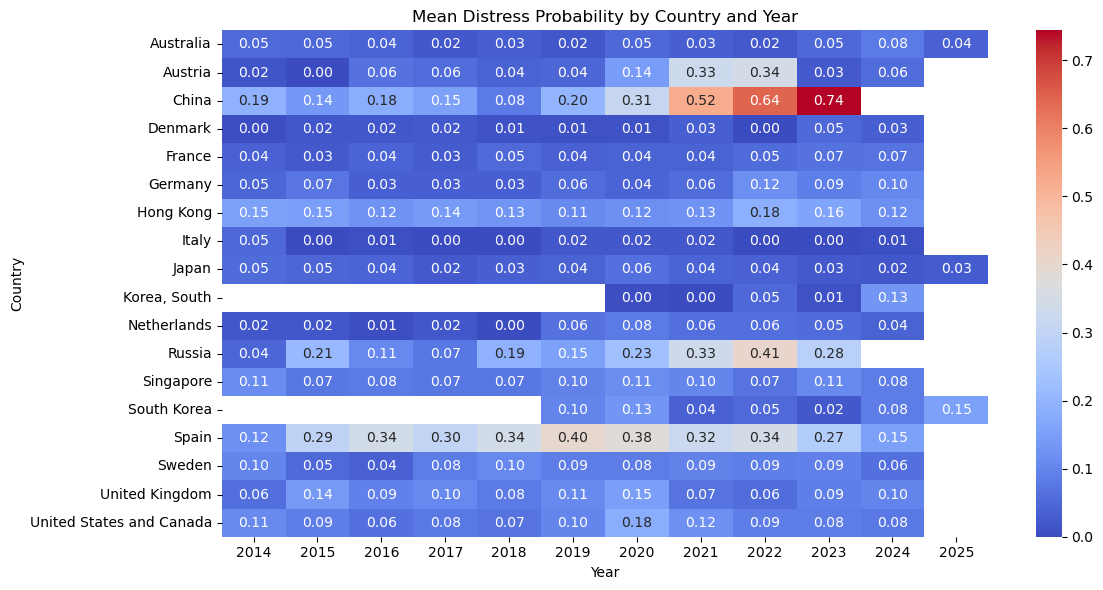


=== PREDICTED DISTRESS COUNT BY COUNTRY AND YEAR ===
Year                      2014  2015  2016  2017  2018  2019  2020  2021  \
Country                                                                    
Australia                  1.0   2.0   0.0   0.0   0.0   0.0   1.0   0.0   
Austria                    0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   
China                      1.0   0.0   1.0   0.0   0.0   1.0   3.0   5.0   
Denmark                    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
France                     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
Germany                    0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   
Hong Kong                  4.0   4.0   3.0   2.0   2.0   2.0   2.0   2.0   
Italy                      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
Japan                      4.0   0.0   1.0   1.0   1.0   1.0   2.0   2.0   
Korea, South               NaN   NaN   NaN   NaN   NaN   NaN   0.0   0.0   
Netherlands                0.0   0

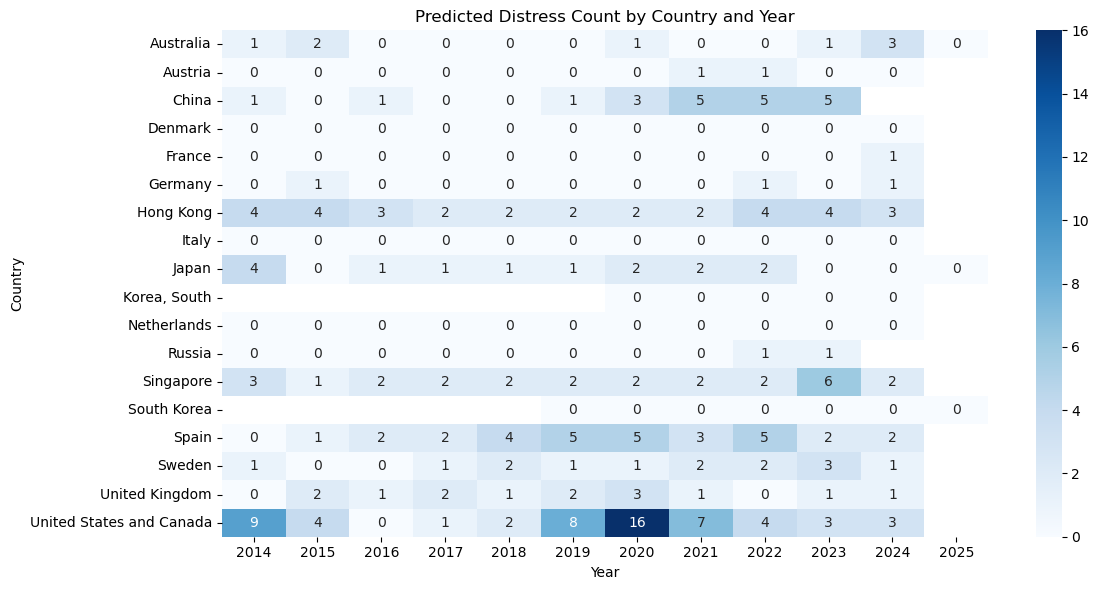


=== UNIQUE COMPANIES BY COUNTRY AND YEAR ===
Year                       2014   2015   2016   2017   2018   2019   2020  \
Country                                                                     
Australia                  27.0   28.0   29.0   30.0   32.0   31.0   32.0   
Austria                     2.0    1.0    2.0    2.0    2.0    2.0    2.0   
China                       8.0    8.0    8.0    8.0    8.0    8.0    8.0   
Denmark                     1.0    1.0    1.0    1.0    1.0    1.0    1.0   
France                     19.0   20.0   20.0   19.0   20.0   20.0   20.0   
Germany                    14.0   15.0   15.0   15.0   15.0   15.0   15.0   
Hong Kong                  32.0   32.0   33.0   34.0   36.0   36.0   36.0   
Italy                       1.0    1.0    1.0    1.0    1.0    1.0    1.0   
Japan                      52.0   55.0   60.0   65.0   65.0   67.0   67.0   
Korea, South                NaN    NaN    NaN    NaN    NaN    NaN    1.0   
Netherlands                 5.

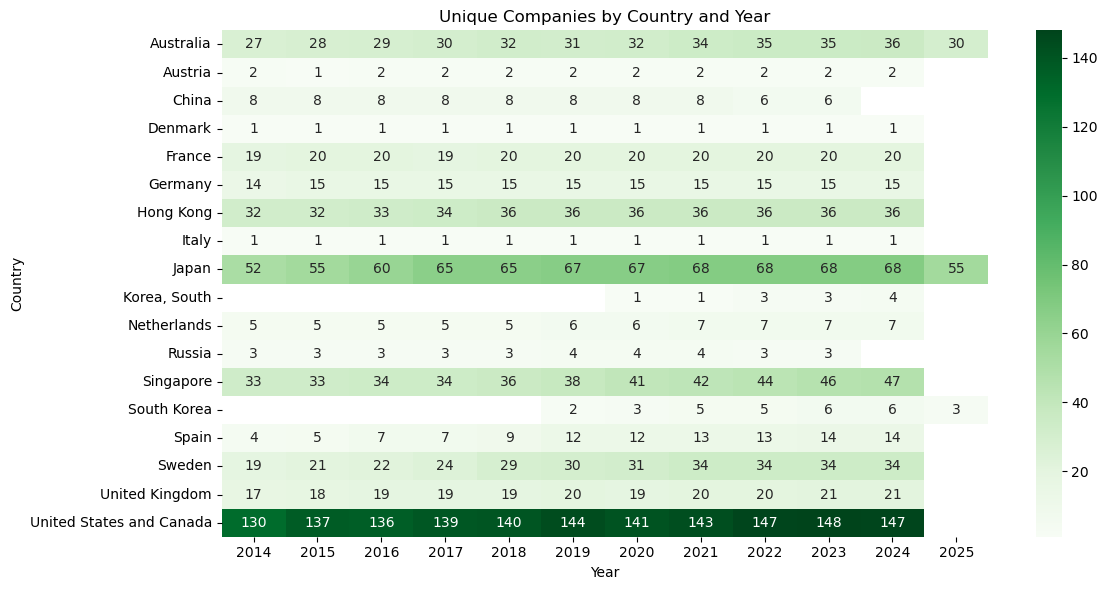


=== PRIMARY INDUSTRY CLASSIFICATION ANALYSIS ===
                                 Mean_Probability  Std_Probability  \
Primary Industry Classification                                      
Real Estate                                0.2688           0.2730   
Real Estate Development                    0.2007           0.2262   
Hotel and Resort REITs                     0.1419           0.2348   
Real Estate Operating Companies            0.0883           0.1571   
Single-Family Residential REITs            0.0860           0.1251   
Health Care REITs                          0.0801           0.1526   
Timber REITs                               0.0769           0.1078   
Multi-Family Residential REITs             0.0683           0.1522   
Data Center REITs                          0.0592           0.1278   
Other Specialized REITs                    0.0586           0.0973   
Office REITs                               0.0545           0.1165   
Diversified REITs                       

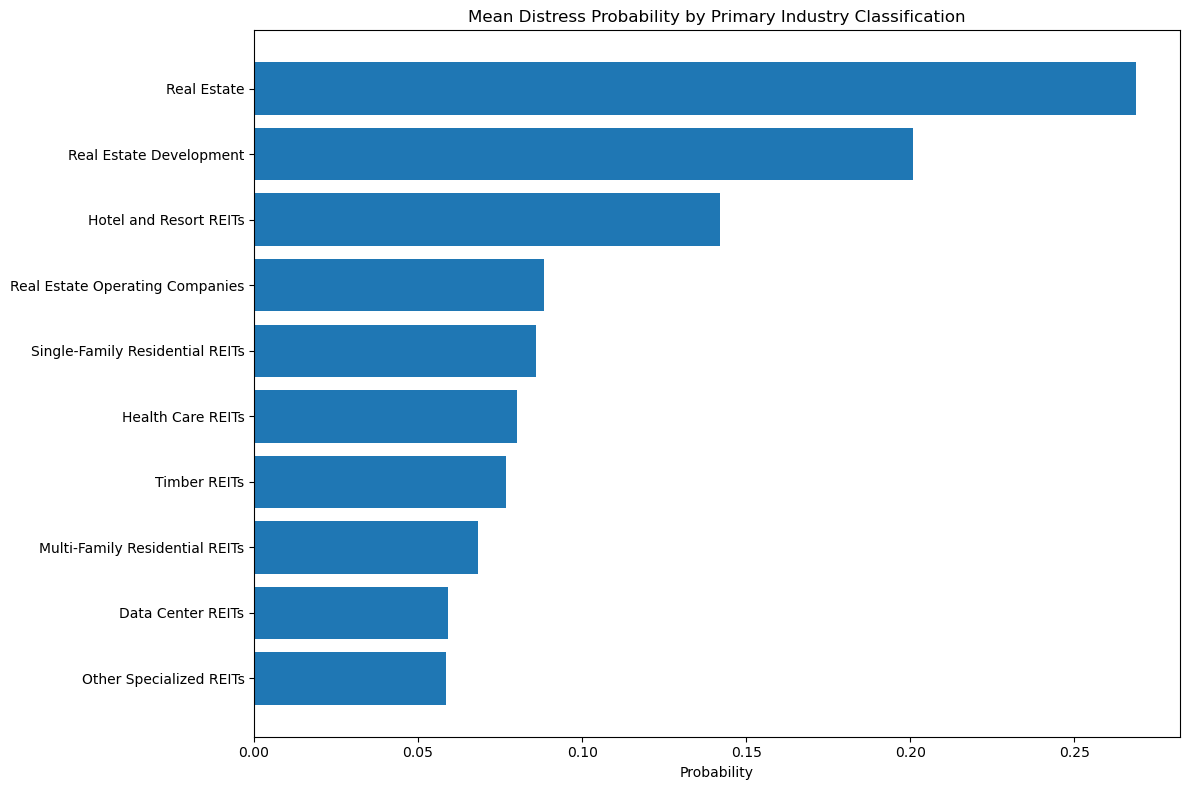


=== MEAN DISTRESS PROBABILITY BY INDUSTRY AND YEAR ===
Year                              2014   2015   2016   2017   2018   2019  \
Primary Industry Classification                                             
Data Center REITs                0.040  0.059  0.021  0.016  0.004  0.011   
Diversified REITs                0.067  0.089  0.066  0.039  0.054  0.039   
Health Care REITs                0.109  0.079  0.040  0.033  0.037  0.061   
Hotel and Resort REITs           0.036  0.027  0.073  0.040  0.078  0.229   
Industrial REITs                 0.031  0.034  0.044  0.039  0.025  0.032   
Multi-Family Residential REITs   0.057  0.043  0.052  0.062  0.061  0.066   
Office REITs                     0.053  0.051  0.034  0.035  0.034  0.051   
Other Specialized REITs          0.098  0.088  0.034  0.082  0.044  0.035   
Real Estate                      0.151  0.156  0.162  0.131  0.111  0.183   
Real Estate Development          0.204  0.192  0.169  0.177  0.219  0.187   
Real Estate Operatin

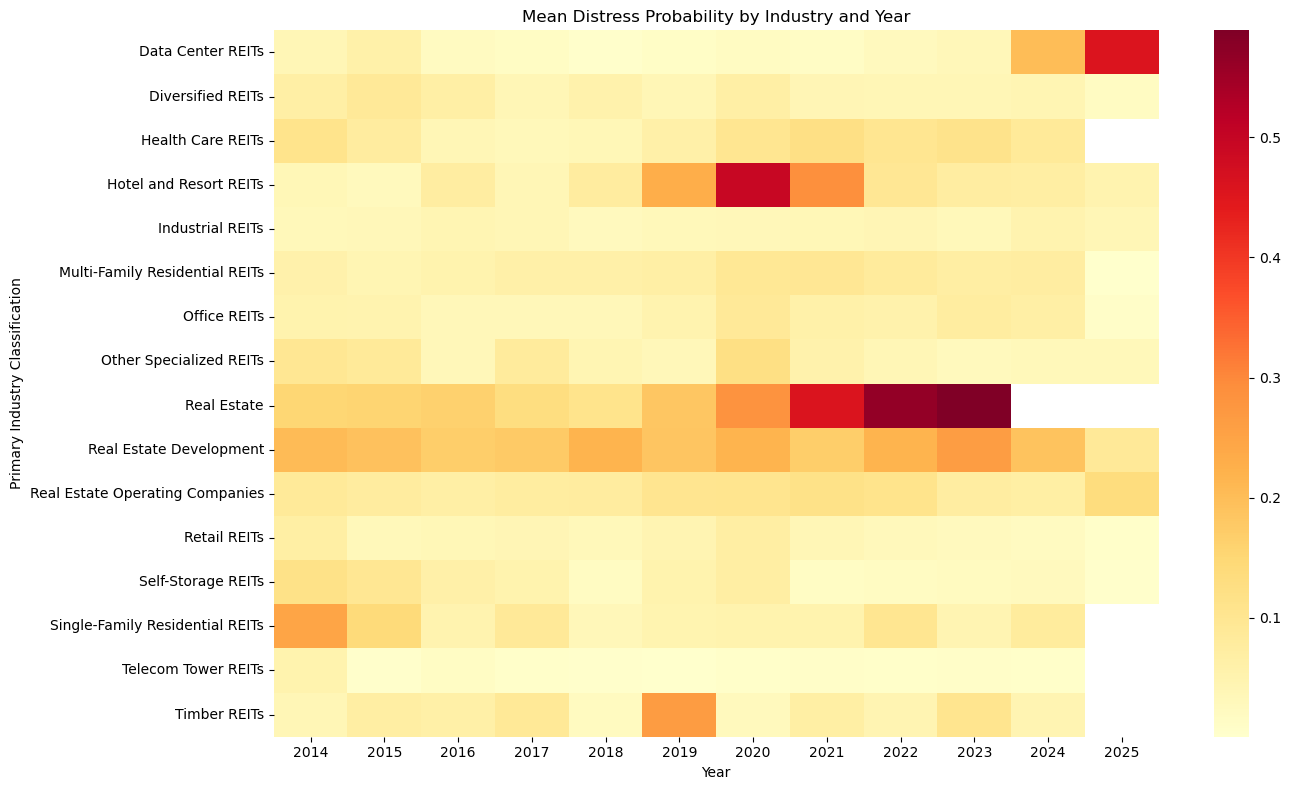


=== YEARLY RISK DYNAMICS ===
      Mean_Probability  Std_Probability  Predicted_Distress_Count  \
Year                                                                
2014            0.0856           0.1613                        23   
2015            0.0765           0.1397                        15   
2016            0.0654           0.1259                        10   
2017            0.0642           0.1273                        11   
2018            0.0666           0.1322                        14   
2019            0.0808           0.1598                        22   
2020            0.1165           0.2019                        35   
2021            0.0943           0.1760                        25   
2022            0.0855           0.1741                        27   
2023            0.0844           0.1672                        26   
2024            0.0691           0.1341                        17   
2025            0.0358           0.0860                         0   

   

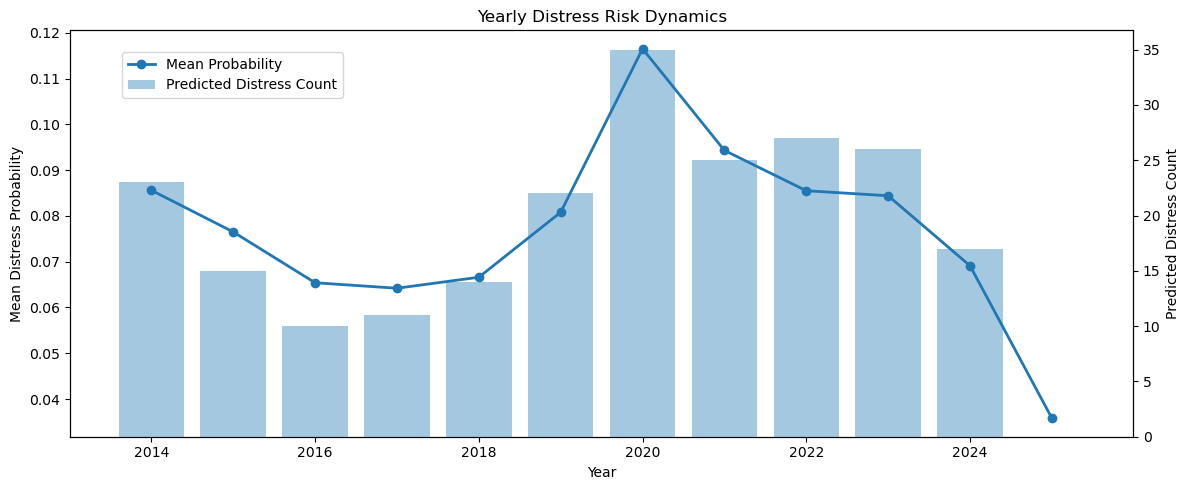


=== TOP 10 HIGHEST RISK OBSERVATIONS ===
                                  Company Name Primary Industry Classification                  Country  Year  Forecast_Year  Distress_Probability  Predicted_Distress
      Árima Real Estate SOCIMI, S.A. (BME:ARM)                    Office REITs                    Spain  2021           2022              0.951096                   1
            Leopalace21 Corporation (TSE:8848) Real Estate Operating Companies                    Japan  2021           2022              0.947072                   1
             Shaftesbury Capital PLC (LSE:SHC)               Diversified REITs           United Kingdom  2020           2021              0.944749                   1
DiamondRock Hospitality Company (NasdaqGS:DRH)          Hotel and Resort REITs United States and Canada  2020           2021              0.942028                   1
                 Shimao Group Holdings Limited                     Real Estate                    China  2021           202

C:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


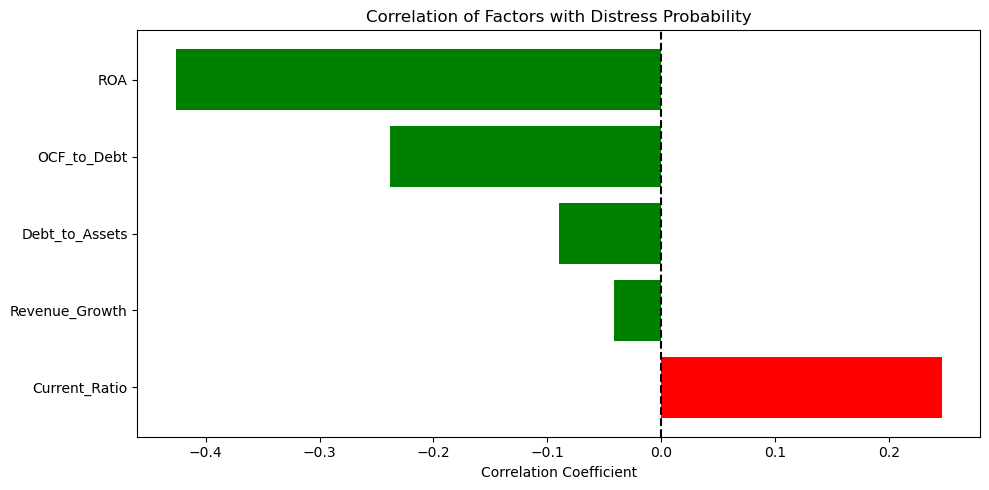


Saved: real_estate_distress_predictions_full.xlsx


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Проверка наличия основных объектов
# --------------------------------------------------
print("X_clean shape:", X_clean.shape if 'X_clean' in dir() else "Not defined")
print("y_clean shape:", y_clean.shape if 'y_clean' in dir() else "Not defined")

# --------------------------------------------------
# 2. Создание df_final, если его ещё нет
# --------------------------------------------------
if 'df_final' not in dir():
    df_final = df.loc[X_clean.index].copy() if 'df' in dir() and 'X_clean' in dir() else None

    if df_final is not None:
        # добавляем признаки из X_clean
        for col in X_clean.columns:
            df_final[col] = X_clean[col]

        # вероятность дистресса
        df_final["Distress_Probability"] = rf.predict_proba(X_clean)[:, 1]

        # бинарный прогноз
        df_final["Predicted_Distress"] = (
            df_final["Distress_Probability"] >= best_thr_rf
        ).astype(int)

        # год прогноза
        df_final["Forecast_Year"] = df_final["Year"] + 1

        print("df_final created successfully!")
    else:
        print("Cannot create df_final - missing required data")

# --------------------------------------------------
# 3. Основной анализ
# --------------------------------------------------
if df_final is not None:

    # ==============================================
    # A. Анализ по странам
    # ==============================================
    country_analysis = df_final.groupby("Country").agg({
        "Distress_Probability": ["mean", "std", "count"],
        "Predicted_Distress": "sum",
        "Company Name": "nunique",
        "Year": "nunique"
    }).round(4)

    country_analysis.columns = [
        "Mean_Probability",
        "Std_Probability",
        "Observations_Count",
        "Predicted_Distress_Count",
        "Unique_Companies",
        "Years_Covered"
    ]

    country_analysis = country_analysis.sort_values("Mean_Probability", ascending=False)

    print("\n=== COUNTRY ANALYSIS ===")
    print(country_analysis)

    # ==============================================
    # B. Страны × годы: средняя вероятность
    # ==============================================
    country_year_prob = df_final.pivot_table(
        index="Country",
        columns="Year",
        values="Distress_Probability",
        aggfunc="mean"
    ).round(3)

    print("\n=== MEAN DISTRESS PROBABILITY BY COUNTRY AND YEAR ===")
    print(country_year_prob)

    plt.figure(figsize=(12, 6))
    sns.heatmap(country_year_prob, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Mean Distress Probability by Country and Year")
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # C. Страны × годы: число distress
    # ==============================================
    country_year_distress = df_final.pivot_table(
        index="Country",
        columns="Year",
        values="Predicted_Distress",
        aggfunc="sum"
    )

    print("\n=== PREDICTED DISTRESS COUNT BY COUNTRY AND YEAR ===")
    print(country_year_distress)

    plt.figure(figsize=(12, 6))
    sns.heatmap(country_year_distress, annot=True, fmt=".0f", cmap="Blues")
    plt.title("Predicted Distress Count by Country and Year")
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # D. Страны × годы: число уникальных компаний
    # ==============================================
    country_year_companies = df_final.pivot_table(
        index="Country",
        columns="Year",
        values="Company Name",
        aggfunc="nunique"
    )

    print("\n=== UNIQUE COMPANIES BY COUNTRY AND YEAR ===")
    print(country_year_companies)

    plt.figure(figsize=(12, 6))
    sns.heatmap(country_year_companies, annot=True, fmt=".0f", cmap="Greens")
    plt.title("Unique Companies by Country and Year")
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # E. Анализ по типам REIT / индустриям
    # ==============================================
    print("\n=== PRIMARY INDUSTRY CLASSIFICATION ANALYSIS ===")
    industry_analysis = df_final.groupby("Primary Industry Classification").agg({
        "Distress_Probability": ["mean", "std", "count"],
        "Predicted_Distress": "sum",
        "Company Name": "nunique",
        "Year": "nunique"
    }).round(4)

    industry_analysis.columns = [
        "Mean_Probability",
        "Std_Probability",
        "Observations_Count",
        "Predicted_Distress_Count",
        "Unique_Companies",
        "Years_Covered"
    ]

    industry_analysis = industry_analysis.sort_values("Mean_Probability", ascending=False)
    print(industry_analysis.head(15))

    plt.figure(figsize=(12, 8))
    top_industries = industry_analysis.head(10).sort_values("Mean_Probability", ascending=True)
    plt.barh(top_industries.index, top_industries["Mean_Probability"])
    plt.title("Mean Distress Probability by Primary Industry Classification")
    plt.xlabel("Probability")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # F. Индустрии × годы
    # ==============================================
    industry_year_prob = df_final.pivot_table(
        index="Primary Industry Classification",
        columns="Year",
        values="Distress_Probability",
        aggfunc="mean"
    ).round(3)

    print("\n=== MEAN DISTRESS PROBABILITY BY INDUSTRY AND YEAR ===")
    print(industry_year_prob.head(15))

    plt.figure(figsize=(14, 8))
    sns.heatmap(industry_year_prob, annot=False, cmap="YlOrRd")
    plt.title("Mean Distress Probability by Industry and Year")
    plt.xlabel("Year")
    plt.ylabel("Primary Industry Classification")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # G. Годовая динамика риска
    # ==============================================
    print("\n=== YEARLY RISK DYNAMICS ===")
    yearly_analysis = df_final.groupby("Year").agg({
        "Distress_Probability": ["mean", "std"],
        "Predicted_Distress": "sum",
        "Company Name": "nunique"
    }).round(4)

    yearly_analysis.columns = [
        "Mean_Probability",
        "Std_Probability",
        "Predicted_Distress_Count",
        "Unique_Companies"
    ]
    print(yearly_analysis)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        yearly_analysis.index,
        yearly_analysis["Mean_Probability"],
        marker="o",
        linewidth=2,
        label="Mean Probability"
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Mean Distress Probability")

    ax2 = ax1.twinx()
    ax2.bar(
        yearly_analysis.index,
        yearly_analysis["Predicted_Distress_Count"],
        alpha=0.4,
        label="Predicted Distress Count"
    )
    ax2.set_ylabel("Predicted Distress Count")

    plt.title("Yearly Distress Risk Dynamics")
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()

    # ==============================================
    # H. Top-10 самых рискованных наблюдений
    # ==============================================
    print("\n=== TOP 10 HIGHEST RISK OBSERVATIONS ===")
    top_risky = df_final.nlargest(10, "Distress_Probability")[[
        "Company Name",
        "Primary Industry Classification",
        "Country",
        "Year",
        "Forecast_Year",
        "Distress_Probability",
        "Predicted_Distress"
    ]]
    print(top_risky.to_string(index=False))

    # ==============================================
    # I. Рейтинг компаний по среднему риску
    # ==============================================
    print("\n=== TOP 20 COMPANIES BY MEAN DISTRESS PROBABILITY ===")
    company_risk = (
        df_final
        .groupby(
            ["Company Name", "Country", "Primary Industry Classification"]
        )["Distress_Probability"]
        .mean()
        .reset_index()
        .sort_values("Distress_Probability", ascending=False)
    )

    print(company_risk.head(20).to_string(index=False))

    # ==============================================
    # J. Корреляция факторов с Distress_Probability
    # ==============================================
    print("\n=== CORRELATION WITH DISTRESS PROBABILITY ===")
    risk_factors = [
        "Debt_to_Assets",
        "Current_Ratio",
        "ROA",
        "OCF_to_Debt",
        "Revenue_Growth",
        "Interest_Coverage"
    ]

    correlations = {}
    for factor in risk_factors:
        if factor in df_final.columns:
            correlations[factor] = df_final[factor].corr(df_final["Distress_Probability"])

    corr_df = pd.DataFrame(
        list(correlations.items()),
        columns=["Factor", "Correlation"]
    ).sort_values("Correlation", ascending=False)

    print(corr_df.to_string(index=False))

    plt.figure(figsize=(10, 5))
    colors = ["red" if x > 0 else "green" for x in corr_df["Correlation"]]
    plt.barh(corr_df["Factor"], corr_df["Correlation"], color=colors)
    plt.axvline(x=0, color="black", linestyle="--")
    plt.title("Correlation of Factors with Distress Probability")
    plt.xlabel("Correlation Coefficient")
    plt.tight_layout()
    plt.show()

    # ==============================================
    # K. Сохранение итогового датасета
    # ==============================================
    df_final.to_excel("real_estate_distress_predictions_full.xlsx", index=False)
    print("\nSaved: real_estate_distress_predictions_full.xlsx")

else:
    print("Please ensure df_final, X_clean, and rf model are available")
    print("Run the earlier cells in the notebook first")



#  Risk Analysis by Region, Industry, and Time 

# SHAP analysis
### Показывает как каждый фактор повышает или снижает риск distress на уровне наблюдений

In [367]:
!pip install shap

 99%|===================| 3326/3364 [00:37<00:00]        

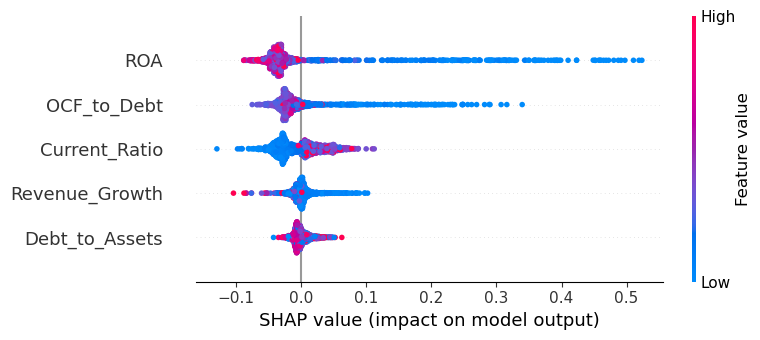

In [617]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

# если SHAP вернул значения для двух классов, берем класс 1
if len(shap_values.values.shape) == 3:
    shap_values_class1 = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    )
else:
    shap_values_class1 = shap_values

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_class1, max_display=10, show=False)
plt.tight_layout()
plt.show()

In [53]:
from sklearn.metrics import confusion_matrix

# прогноз по лучшему порогу
y_pred_rf = (y_proba_rf >= best_thr_rf).astype(int)

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negatives:", TN)
print("False Positives (Type I error):", FP)
print("False Negatives (Type II error):", FN)
print("True Positives:", TP)

# доли ошибок
type1_rate = FP / (FP + TN)
type2_rate = FN / (FN + TP)

print("\nType I error rate:", type1_rate)
print("Type II error rate:", type2_rate)

Confusion matrix:
[[1617   35]
 [   8   22]]

True Negatives: 1617
False Positives (Type I error): 35
False Negatives (Type II error): 8
True Positives: 22

Type I error rate: 0.0211864406779661
Type II error rate: 0.26666666666666666


In [597]:
print(best_thr_rf)

0.4951515151515152


In [404]:
print(thresholds)

[0.01       0.01989899 0.02979798 0.03969697 0.04959596 0.05949495
 0.06939394 0.07929293 0.08919192 0.09909091 0.1089899  0.11888889
 0.12878788 0.13868687 0.14858586 0.15848485 0.16838384 0.17828283
 0.18818182 0.19808081 0.2079798  0.21787879 0.22777778 0.23767677
 0.24757576 0.25747475 0.26737374 0.27727273 0.28717172 0.29707071
 0.3069697  0.31686869 0.32676768 0.33666667 0.34656566 0.35646465
 0.36636364 0.37626263 0.38616162 0.39606061 0.4059596  0.41585859
 0.42575758 0.43565657 0.44555556 0.45545455 0.46535354 0.47525253
 0.48515152 0.49505051 0.50494949 0.51484848 0.52474747 0.53464646
 0.54454545 0.55444444 0.56434343 0.57424242 0.58414141 0.5940404
 0.60393939 0.61383838 0.62373737 0.63363636 0.64353535 0.65343434
 0.66333333 0.67323232 0.68313131 0.6930303  0.70292929 0.71282828
 0.72272727 0.73262626 0.74252525 0.75242424 0.76232323 0.77222222
 0.78212121 0.7920202  0.80191919 0.81181818 0.82171717 0.83161616
 0.84151515 0.85141414 0.86131313 0.87121212 0.88111111 0.89101

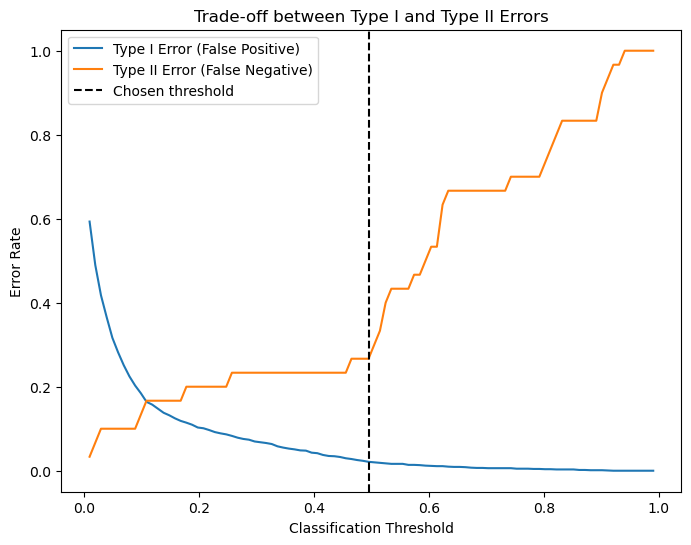

In [612]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.99, 100)

type1_errors = []
type2_errors = []

for t in thresholds:
    
    y_pred = (y_proba_rf >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    TN, FP, FN, TP = cm.ravel()
    
    type1 = FP / (FP + TN)
    type2 = FN / (FN + TP)
    
    type1_errors.append(type1)
    type2_errors.append(type2)

plt.figure(figsize=(8,6))

plt.plot(thresholds, type1_errors, label="Type I Error (False Positive)")
plt.plot(thresholds, type2_errors, label="Type II Error (False Negative)")

plt.axvline(best_thr_rf, linestyle="--", color="black", label="Chosen threshold")

plt.xlabel("Classification Threshold")
plt.ylabel("Error Rate")
plt.title("Trade-off between Type I and Type II Errors")
plt.legend()

plt.show()

In [545]:
print(best_thr_xgb)

0.2


In [112]:
# создаём финальный dataframe
df_final = df.copy()

# оставляем только наблюдения модели
df_final = df_final.loc[X_clean.index].copy()

# добавляем экономические показатели
df_final["Debt_to_Assets"] = X_clean["Debt_to_Assets"]
df_final["Current_Ratio"] = X_clean["Current_Ratio"]
df_final["ROA"] = X_clean["ROA"]
df_final["OCF_to_Debt"] = X_clean["OCF_to_Debt"]
df_final["Revenue_Growth"] = X_clean["Revenue_Growth"]
df_final["Interest_Coverage"] = X_clean["Interest_Coverage"]

# вероятность distress
df_final["Distress_Probability"] = rf.predict_proba(X_clean)[:,1]

# бинарный прогноз
df_final["Predicted_Distress"] = (df_final["Distress_Probability"] >= best_thr_rf).astype(int)

# год прогноза
df_final["Forecast_Year"] = df_final["Year"] + 1

# оставляем нужные поля
columns_keep = [
    "Company Name",
    "Exchange:Ticker",
    "Geographic Locations",
    "Primary Industry",
    
    "Year",
    "Forecast_Year",
    
    "Distress",
    "Distress_next_year",
    
    "FY Total Assets",
    "FY Total Debt",
    "FY Total Revenue",
    "FY EBIT",
    "FY Cash from Ops.",
    
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth",
    "Interest_Coverage",
    
    "Distress_Probability",
    "Predicted_Distress"
]

df_final = df_final[columns_keep]

print("Final dataset shape:", df_final.shape)
df_final.head()

Final dataset shape: (2469, 21)


,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress,Distress_next_year,FY Total Assets,FY Total Debt,...,FY EBIT,FY Cash from Ops.,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth,Interest_Coverage,Distress_Probability,Predicted_Distress
2915,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2015,2016,0,0.0,1068.8,396.7,...,35.4,90.61,0.371164,21.095238,0.033121,0.228409,5.233333,9.340369,0.146961,0
2645,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2016,2017,0,0.0,1287.3,474.7,...,44.7,78.28,0.368756,1.559678,0.034724,0.164904,0.250267,10.022422,0.011200,0
2375,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2017,2018,0,0.0,1752.4,748.0,...,56.3,84.23,0.426843,1.492184,0.032127,0.112607,0.233533,10.180832,0.003198,0
2105,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2018,2019,0,0.0,2283.6,944.4,...,74.9,96.20,0.413558,0.635333,0.032799,0.101864,0.328710,10.190476,0.005260,0
1835,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2019,2020,0,0.0,2281.1,944.4,...,78.8,212.65,0.414011,1.063183,0.034545,0.225169,0.068894,10.287206,0.007173,0


# Выведем ТОП-20

In [113]:
risk_ranking = (
    df_final
    .sort_values("Distress_Probability", ascending=False)
    .reset_index(drop=True)
)

risk_ranking.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress,Distress_next_year,FY Total Assets,FY Total Debt,...,FY EBIT,FY Cash from Ops.,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth,Interest_Coverage,Distress_Probability,Predicted_Distress
0,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,1,1.0,2063.5,1554.5,...,18.2,73.27,0.753332,3.601203,0.008820,0.047134,0.070312,0.407889,0.988701,1
1,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,1,1.0,2434.1,1615.9,...,-14.7,12.59,0.663859,3.764449,-0.006039,0.007791,0.121471,-0.277883,0.986731,1
2,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2017,2018,1,1.0,1055.4,792.8,...,13.3,37.51,0.751184,3.658886,0.012602,0.047313,0.085843,0.449628,0.981681,1
3,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2020,2021,1,1.0,1840.5,1068.9,...,2.3,47.85,0.580766,6.035452,0.001250,0.044766,0.053250,0.083606,0.980540,1
4,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2018,2019,1,1.0,7381.8,5412.8,...,52.2,93.10,0.733263,1.251766,0.007071,0.017200,-0.010157,0.219144,0.979187,1
5,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2019,2020,1,1.0,1866.0,1404.0,...,14.9,51.37,0.752412,4.536323,0.007985,0.036588,0.235334,0.398502,0.978565,1
6,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,2020,2021,1,1.0,1167.2,952.6,...,-0.2,31.72,0.816141,1.800000,-0.000171,0.033298,0.152218,-0.007446,0.977775,1
7,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2017,2018,1,1.0,7724.8,5661.9,...,56.2,73.00,0.732951,1.126700,0.007275,0.012893,0.157615,0.258153,0.977529,1
8,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2016,2017,1,1.0,7656.6,4890.2,...,22.5,102.90,0.638691,2.626506,0.002939,0.021042,0.153002,0.117432,0.976474,1
9,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2024,2025,1,1.0,6961.1,4784.9,...,48.7,55.10,0.687377,1.035913,0.006996,0.011515,-0.051011,0.186519,0.976052,1


In [ ]:
company_risk = (
    df_final
    .groupby(["Company Name","Exchange:Ticker","Geographic Locations","Primary Industry"])
    ["Distress_Probability"]
    .mean()
    .reset_index()
)

company_risk = company_risk.sort_values(
    "Distress_Probability",
    ascending=False
)

company_risk.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Distress_Probability
145,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,0.972959
16,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,0.941048
180,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,0.938712
115,"Hines Global Income Trust, Inc. (MutualFund:ZH...",MutualFund:ZHGI.DX,United States and Canada (Primary),Diversified REITs,0.932937
232,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,0.924274
255,"Veris Residential, Inc. (NYSE:VRE)",NYSE:VRE,United States and Canada (Primary),Multi-Family Residential REITs,0.893678
3,Acadia Realty Trust (NYSE:AKR),NYSE:AKR,United States and Canada (Primary),Retail REITs,0.888048
159,"Lineage, Inc. (NasdaqGS:LINE)",NasdaqGS:LINE,United States and Canada (Primary),Industrial REITs,0.867847
39,Centerspace (NYSE:CSR),NYSE:CSR,United States and Canada (Primary),Multi-Family Residential REITs,0.824068
12,"American Healthcare REIT, Inc. (NYSE:AHR)",NYSE:AHR,United States and Canada (Primary),Health Care REITs,0.810261


In [ ]:
df_final.to_csv("real_estate_distress_panel_predictions.csv", index=False)

company_risk.to_csv("real_estate_company_risk_ranking.csv", index=False)

In [ ]:
import os

os.makedirs("images", exist_ok=True)

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# создаём папку для изображений
os.makedirs("images", exist_ok=True)

# создаём dataframe только из признаков
df_plot = pd.DataFrame(X_clean, columns=X_clean.columns)

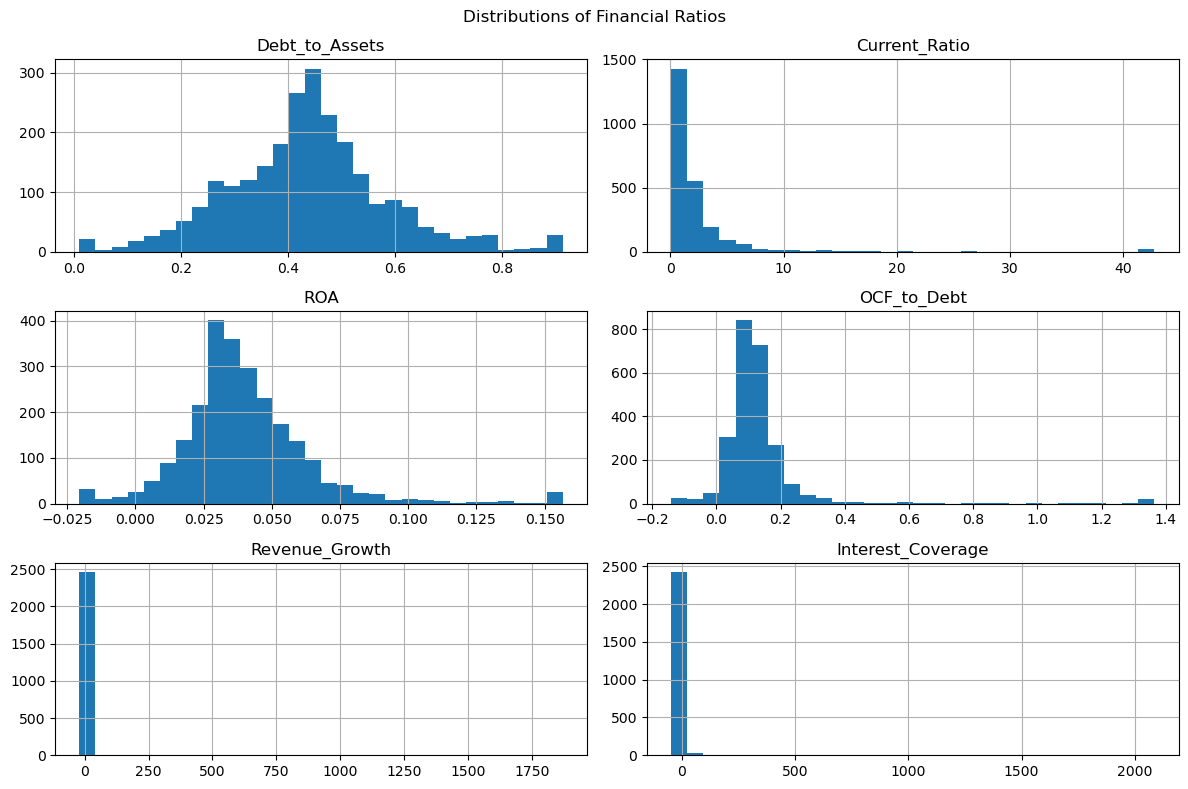

In [ ]:
df_plot.hist(figsize=(12,8), bins=30)

plt.suptitle("Distributions of Financial Ratios")
plt.tight_layout()

plt.savefig("images/feature_histograms.png", dpi=300)
plt.show()

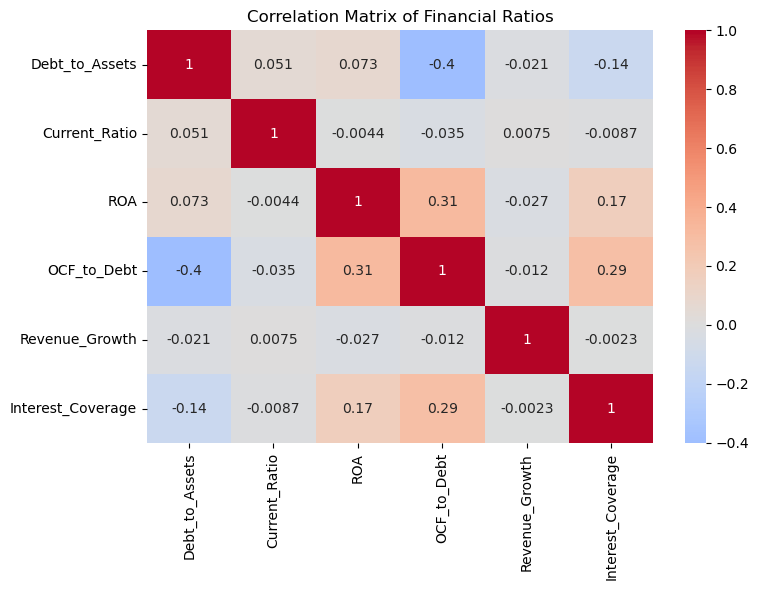

In [ ]:
corr = df_plot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial Ratios")

plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=300)
plt.show()

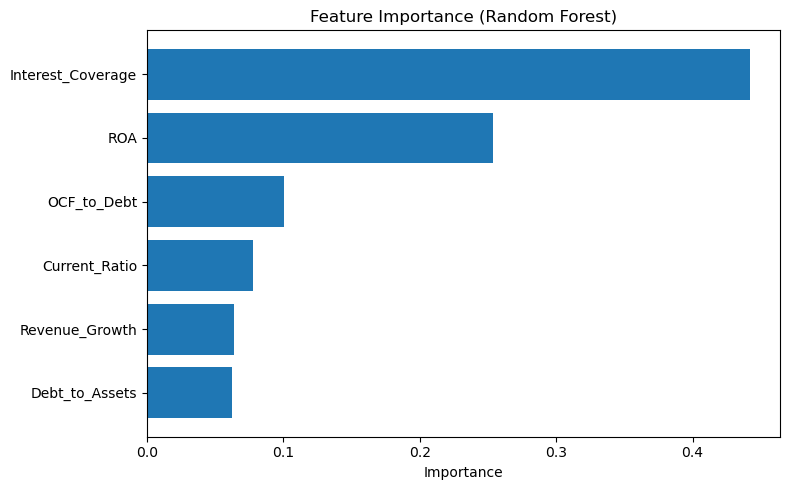

In [ ]:
importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300)
plt.show()

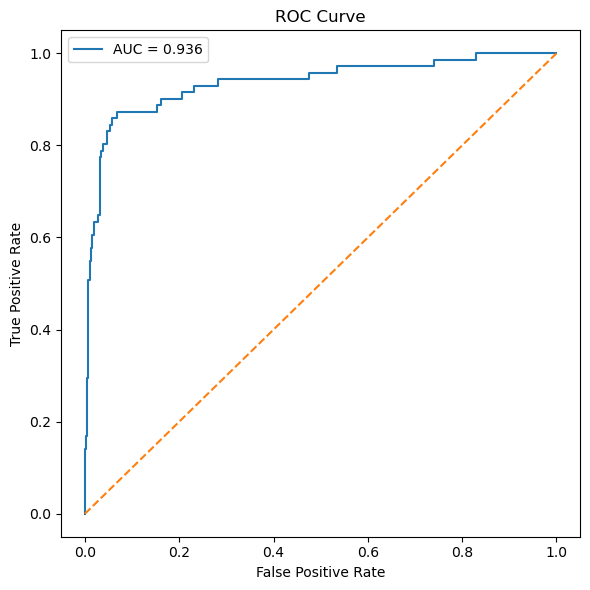

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300)
plt.show()

In [ ]:
distress_companies = df_final[df_final["Distress"] == 1][[
    "Company Name",
    "Exchange:Ticker",
    "Geographic Locations",
    "Primary Industry",
    "Year",
    "Forecast_Year",
    "Distress_Probability"
]]

distress_companies = distress_companies.sort_values(
    "Distress_Probability",
    ascending=False
)

distress_companies.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress_Probability
1306,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,0.988701
1335,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,0.986731
2386,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2017,2018,0.981681
1605,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2020,2021,0.980540
1898,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2018,2019,0.979187
1846,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2019,2020,0.978565
1518,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,2020,2021,0.977775
2168,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2017,2018,0.977529
2438,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2016,2017,0.976474
278,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2024,2025,0.976052


In [ ]:
print(distress_companies.head(100).to_markdown(index=False))

| Company Name                                           | Exchange:Ticker    | Geographic Locations               | Primary Industry                |   Year |   Forecast_Year |   Distress_Probability |
|:-------------------------------------------------------|:-------------------|:-----------------------------------|:--------------------------------|-------:|----------------:|-----------------------:|
| NexPoint Residential Trust, Inc. (NYSE:NXRT)           | NYSE:NXRT          | United States and Canada (Primary) | Multi-Family Residential REITs  |   2021 |            2022 |               0.988701 |
| Apartment Investment and Management Company (NYSE:AIV) | NYSE:AIV           | United States and Canada (Primary) | Multi-Family Residential REITs  |   2021 |            2022 |               0.986731 |
| NexPoint Residential Trust, Inc. (NYSE:NXRT)           | NYSE:NXRT          | United States and Canada (Primary) | Multi-Family Residential REITs  |   2017 |            2018 |           